# Swiggy Data Analysis — Trends, Pricing, and Restaurant Rankings


#### Insight 1 — Demand/Activity is stable month-to-month (no big seasonality in this window)
#### Insight 2 — Prices are also stable (avg and median barely move)
#### Insight 3 — Higher price does not reliably mean higher rating
#### Insight 4 — Prediction (next 3 months): activity will remain flat around ~25.1k–25.3k rows/month
#### Insight 5 — Cities generate the most revenue?
#### Insight 6 — Which Restaurant generate the most revenue?
#### Insight 7 — Correlation Analysis



### Import all liabaries


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Import raw data


In [2]:
file_path = "C:/Users/lxxsh/Downloads/Swiggy Raw Data Excel (1).xlsx"
df_swiggy = pd.read_excel(file_path, sheet_name='Swiggy Data')


In [3]:
print(df_swiggy.head(5))
print(df_swiggy.shape)

       State       City Order Date           Restaurant Name  \
0  Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1  Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2  Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3  Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4  Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   

               Location     Category             Dish Name  Price (INR)  \
0  Rajarajeshwari Nagar        Snack  Butter Murukku-200gm        133.9   
1               Kengeri  Recommended            Badam Milk         52.0   
2               Kengeri  Recommended        Chow Chow Bath        117.0   
3               Kengeri  Recommended           Kesari Bath         65.0   
4               Kengeri  Recommended            Mix Raitha        130.0   

   Rating  Rating Count  
0     4.0             0  
1     4.5            25  
2     4.7            48  
3     4.6            65  
4     4.0             0  
(197430,

### Clean/feature engineer: parse dates, create month, and compute core aggregates for insights



In [4]:
sw = df_swiggy.copy()

# Ensure datetime
sw['Order Date'] = pd.to_datetime(sw['Order Date'], errors='coerce')

# Numeric coercions
for col_name in ['Price (INR)', 'Rating', 'Rating Count']:
    sw[col_name] = pd.to_numeric(sw[col_name], errors='coerce')

# Basic derived fields
sw['order_month'] = sw['Order Date'].dt.to_period('M').dt.to_timestamp()
sw['order_weekday'] = sw['Order Date'].dt.day_name()

# Core summary
min_dt = sw['Order Date'].min()
max_dt = sw['Order Date'].max()

print(min_dt)
print(max_dt)
print(sw[['State','City','Restaurant Name','Category','Dish Name']].nunique())
print(sw[['Price (INR)','Rating','Rating Count']].describe())


2025-01-01 00:00:00
2025-08-31 00:00:00
State                 28
City                  28
Restaurant Name      993
Category            4972
Dish Name          59064
dtype: int64
         Price (INR)         Rating   Rating Count
count  197430.000000  197430.000000  197430.000000
mean      268.512920       4.341582      28.321805
std       219.338363       0.422585      87.542593
min         0.950000       1.500000       0.000000
25%       139.000000       4.300000       0.000000
50%       229.000000       4.400000       2.000000
75%       329.000000       4.500000      15.000000
max      8000.000000       5.000000     999.000000


##  Build the 3 descriptive insights + 1 forecast: trends, price-rating relationship, and top performers


In [5]:
sw = sw.dropna(subset=['Order Date']).copy()

# Monthly volume and price trend
monthly = (sw.groupby('order_month')
           .agg(rows=('Dish Name','size'),
                avg_price=('Price (INR)','mean'),
                median_price=('Price (INR)','median'),
                avg_rating=('Rating','mean'))
           .reset_index()
           .sort_values('order_month'))

print(monthly)


  order_month   rows   avg_price  median_price  avg_rating
0  2025-01-01  25398  268.729271        229.00    4.344295
1  2025-02-01  23296  269.106528        229.52    4.337311
2  2025-03-01  24402  269.384889        229.00    4.346013
3  2025-04-01  24588  268.200545        229.00    4.338462
4  2025-05-01  25190  269.692672        229.00    4.340838
5  2025-06-01  24385  267.138946        229.00    4.340718
6  2025-07-01  24940  266.678649        229.00    4.340882
7  2025-08-01  25231  269.171333        229.00    4.343819


## Monthly item rows (proxy for menu/order records)

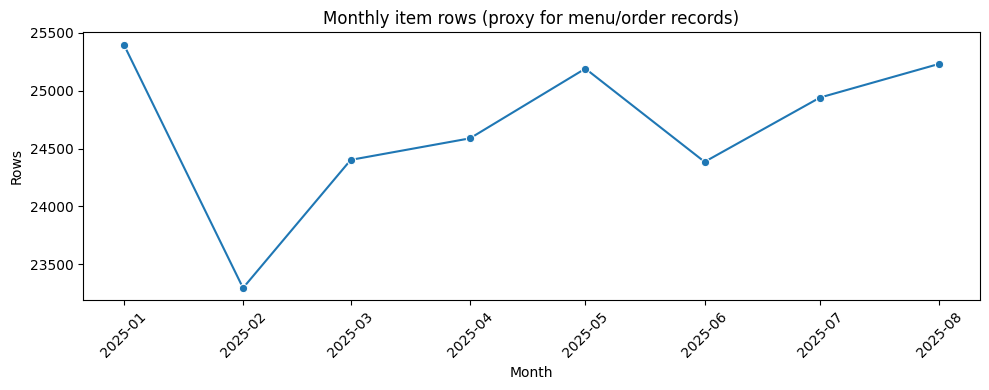

In [6]:
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='order_month', y='rows', marker='o')
plt.title('Monthly item rows (proxy for menu/order records)')
plt.xlabel('Month')
plt.ylabel('Rows')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Monthly price trend

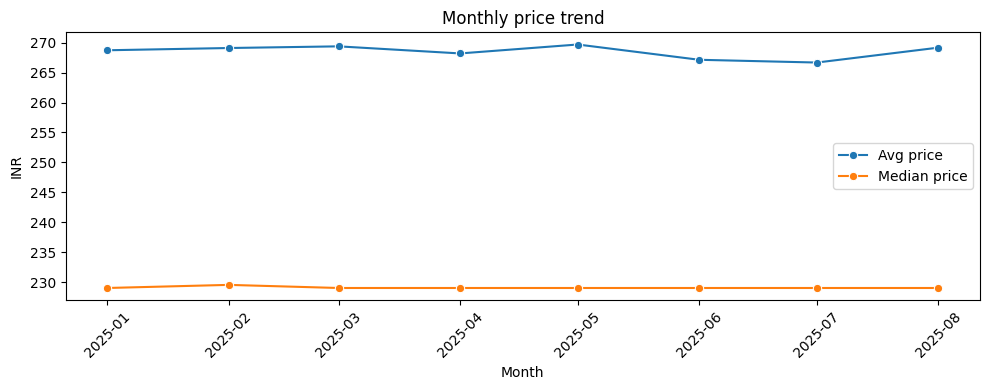

In [7]:
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='order_month', y='avg_price', marker='o', label='Avg price')
sns.lineplot(data=monthly, x='order_month', y='median_price', marker='o', label='Median price')
plt.title('Monthly price trend')
plt.xlabel('Month')
plt.ylabel('INR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Price vs rating relationship (binned)

In [8]:
sw['price_bin'] = pd.qcut(sw['Price (INR)'], q=10, duplicates='drop')
price_rating = (sw.groupby('price_bin')
                .agg(avg_price=('Price (INR)','mean'),
                     avg_rating=('Rating','mean'),
                     n=('Rating','size'))
                .reset_index()
                .sort_values('avg_price'))

print(price_rating[['avg_price','avg_rating','n']].head())



    avg_price  avg_rating      n
0   57.300459    4.349584  19829
1  105.967153    4.350640  20403
2  141.385819    4.334509  19531
3  182.080642    4.324832  23236
4  215.210550    4.320517  16440


C:\Users\lxxsh\AppData\Local\Temp\ipykernel_9240\1286662973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = (sw.groupby('price_bin')


### Avg rating by price decile

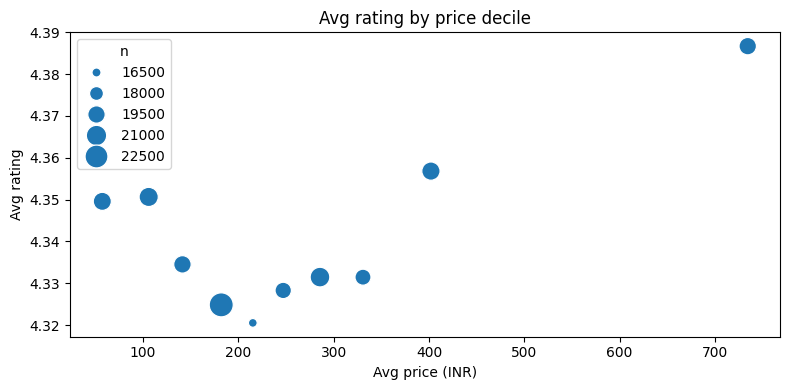

In [9]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=price_rating, x='avg_price', y='avg_rating', size='n', sizes=(40,300))
plt.title('Avg rating by price decile')
plt.xlabel('Avg price (INR)')
plt.ylabel('Avg rating')
plt.tight_layout()
plt.show()



### Top restaurants by weighted rating (Bayesian average) to avoid low-count bias

In [10]:
C = sw['Rating'].mean()
m = sw['Rating Count'].quantile(0.75)
rest = (sw.groupby(['State','City','Restaurant Name'])
        .agg(avg_rating=('Rating','mean'),
             rating_count=('Rating Count','sum'),
             items=('Dish Name','size'),
             avg_price=('Price (INR)','mean'))
        .reset_index())

rest['bayes_rating'] = (rest['rating_count']/(rest['rating_count']+m))*rest['avg_rating'] + (m/(rest['rating_count']+m))*C

rest_top = rest.sort_values(['bayes_rating','rating_count'], ascending=False).head(15)
print(rest_top)


               State         City                   Restaurant Name  \
203            Delhi    New Delhi                 Natural Ice Cream   
259              Goa       Panaji                            Sakana   
507        Jharkhand       Ranchi                    NIC Ice Creams   
324          Gujarat    Ahmedabad                         Theobroma   
359          Haryana      Gurgaon                 Natural Ice Cream   
1545     West Bengal      Kolkata                     Grameen Kulfi   
1555     West Bengal      Kolkata  Kwality Walls Ice Cream and More   
245              Goa       Panaji                     Grameen Kulfi   
1078          Punjab   Chandigarh                       Vijay Dairy   
1440   Uttar Pradesh      Lucknow     Radhey Lal's Parampara Sweets   
630           Kerala        Kochi                       I Deli Cafe   
325          Gujarat    Ahmedabad                Vadilal Ice Creams   
964           Odisha  Bhubaneswar      Jagannath Mandir Arna Prasad   
1472  

### Forecast next 3 months rows using a simple linear trend on monthly rows


In [11]:
monthly_fore = monthly[['order_month','rows']].copy()
monthly_fore['t'] = np.arange(len(monthly_fore))

coef = np.polyfit(monthly_fore['t'], monthly_fore['rows'], 1)

future_months = pd.date_range(monthly_fore['order_month'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
future_t = np.arange(len(monthly_fore), len(monthly_fore)+len(future_months))
future_rows = coef[0]*future_t + coef[1]

forecast_df = pd.DataFrame({'order_month': future_months, 'rows_forecast': future_rows})
print(forecast_df)


  order_month  rows_forecast
0  2025-09-01        25086.0
1  2025-10-01        25176.5
2  2025-11-01        25267.0


### Monthly rows: actual + 3-month forecast (linear trend

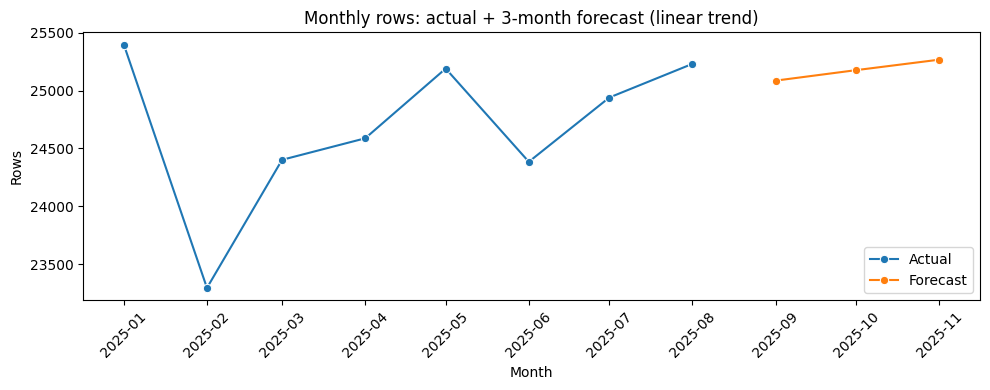

In [12]:
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='order_month', y='rows', marker='o', label='Actual')
sns.lineplot(data=forecast_df, x='order_month', y='rows_forecast', marker='o', label='Forecast')
plt.title('Monthly rows: actual + 3-month forecast (linear trend)')
plt.xlabel('Month')
plt.ylabel('Rows')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Which cities generate the most revenue?


In [13]:
sw['Revenue'] = sw['Price (INR)'] * sw['Rating Count']

In [14]:
sw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
 10  order_month      197430 non-null  datetime64[ns]
 11  order_weekday    197430 non-null  object        
 12  price_bin        197430 non-null  category      
 13  Revenue          197430 non-null  float64       
dtypes: category(1), date

In [15]:
top_cities = sw.groupby('City')['Revenue'].sum().sort_values(ascending=False).head(10)
top_cities_lakh = top_cities / 100000
top_cities_lakh



City
Bengaluru      1164.700905
Chennai         771.619847
Chandigarh      768.236495
Jaipur          651.755359
New Delhi       626.845500
Lucknow         604.283337
Bhubaneswar     586.943033
Kolkata         575.574707
Hyderabad       563.289096
Shillong        517.553929
Name: Revenue, dtype: float64

<Axes: title={'center': 'top cities by revenue'}, xlabel='City'>

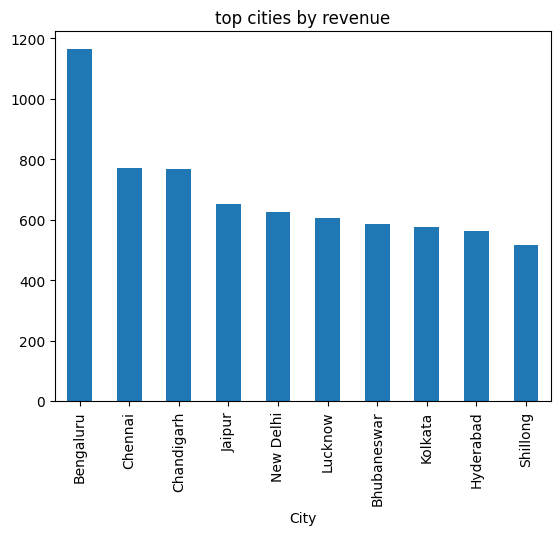

In [16]:
top_cities_lakh.plot(kind='bar', title='top cities by revenue')

#### Insight  — Bengaluru generates the highest revenue, suggesting stronger demand or higher restaurant density.


## Which Restaurant generate the most revenue?


In [17]:
top_restaurants = sw.groupby('Restaurant Name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_restaurants_lakh=top_restaurants/100000
top_restaurants_lakh

Restaurant Name
KFC                               1272.310602
McDonald's                         919.926065
Pizza Hut                          462.004249
Burger King                        420.093468
Domino's Pizza                     215.751270
Urban Pinds Food Factory           186.421330
NIC Ice Creams                     154.143032
LunchBox - Meals and Thalis        149.828945
Olio - The Wood Fired Pizzeria     137.399100
The Good Bowl                      121.051070
Name: Revenue, dtype: float64

<Axes: title={'center': 'Top Restaurant by Revenue'}, xlabel='Restaurant Name'>

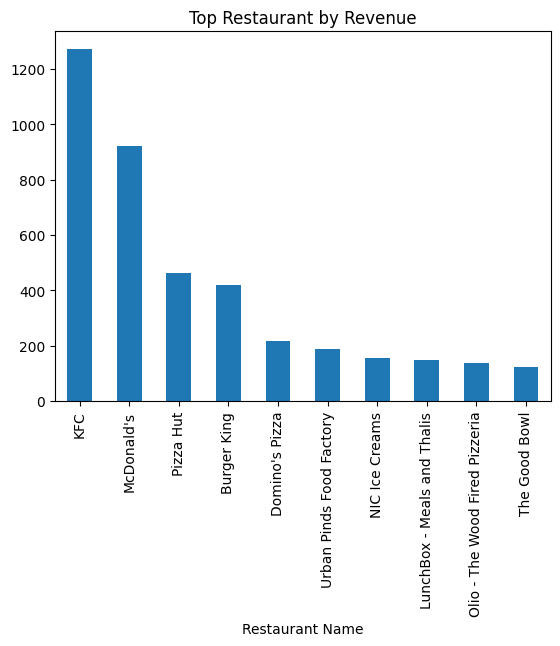

In [18]:
top_restaurants_lakh.plot(kind= 'bar' , title='Top Restaurant by Revenue')

#### Insight  — KFC generates the highest revenue .


## Correlation Analysis

<Axes: >

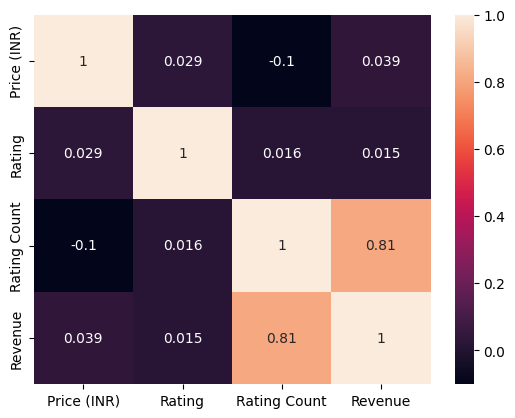

In [19]:
sns.heatmap(sw.corr(numeric_only=True), annot=True)

## Improve Your Charts with seaborn

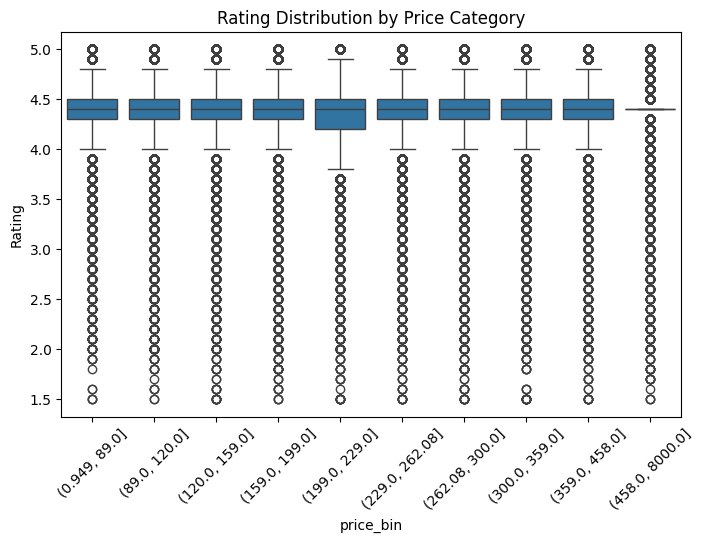

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='price_bin', y='Rating', data=sw)

plt.xticks(rotation=45)
plt.title("Rating Distribution by Price Category")

plt.show()